# Introduction #
## PBA Week 3 ##
Mohammad Geresidi Rachmadi
5026221163 - Sistem Informasi

In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn
!pip install nltk
!pip install Sastrawi
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.3 MB/s eta 0:00:00


## Data Collection ##

Initial Setup

In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import CountVectorizer

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

Get data from = "https://play.google.com/store/apps/details?id=com.seatech.bluebird&hl=en", Online Taxi Mobile Apps.

In [3]:
#https://play.google.com/store/apps/details?id=com.seatech.bluebird&hl=en


from google_play_scraper import app, Sort, reviews_all

mbb_reviews = reviews_all(
    'com.seatech.bluebird',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

Save data into DataFrame

In [4]:
df_mbbrev = pd.DataFrame(np.array(mbb_reviews),columns=['content'])
df_mbbrev = df_mbbrev.join(pd.DataFrame(df_mbbrev.pop('content').tolist()))

Mask Username

In [5]:
def mask_username(username):
    if pd.isna(username):
        return username
    username = str(username)
    if len(username) <= 4:
        return "*" * len(username)
    return username[:2] + "*" * (len(username)-4) + username[-2:]

df_mbbrev['userName'] = df_mbbrev['userName'].apply(mask_username)

Save raw data (with username masking) into .csv

In [6]:
df_mbbrev.to_csv("mybluebird_raw.csv", index=False)

In [7]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method: credit card d...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0
1,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Perusahaan taksi andalan yang legendaris. Maju...,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0
2,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,getting better but can you please give the lic...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2
3,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"good app and service, but too many annoying ad...",4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2
4,6a1c2108-fb3d-4d79-807a-a6c44216cf77,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"nice app, thanks 👍🏾👍🏾",5,0,6.18.2,2025-09-13 02:01:38,"Dear Mr/Ms Andrie Wisnu , thank you for the ra...",2025-09-13 02:05:39,6.18.2
...,...,...,...,...,...,...,...,...,...,...,...
9664,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Great app. Sangat membantu.,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127
9665,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"Akhirnya setelah di blackberry, dibuat juga ap...",5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126
9666,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Pagi jam 4 saya pesan taksi berjalan dengan ba...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126
9667,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Pertama kali make app ini gw seneng banget kar...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126


In [8]:
df_mbbrev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9669 entries, 0 to 9668
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              9669 non-null   object        
 1   userName              9669 non-null   object        
 2   userImage             9669 non-null   object        
 3   content               9663 non-null   object        
 4   score                 9669 non-null   int64         
 5   thumbsUpCount         9669 non-null   int64         
 6   reviewCreatedVersion  8706 non-null   object        
 7   at                    9669 non-null   datetime64[ns]
 8   replyContent          8570 non-null   object        
 9   repliedAt             8570 non-null   datetime64[ns]
 10  appVersion            8706 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 831.1+ KB


## Data Preprocessing ##

Lowercasing

In [9]:
df_mbbrev['content'] = df_mbbrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print ("Before lowercasing:")
print(df_mbbrev['content'][11])
print(df_mbbrev['content'][1])
print(df_mbbrev['content'][20])
print ("\nAfter lowercasing:")
df_mbbrev['content']= df_mbbrev['content'].apply(lambda x: x.lower())
print(df_mbbrev['content'][11])
print(df_mbbrev['content'][1])
print(df_mbbrev['content'][20])

Before lowercasing:
aplikasi sampah gabisa order sama sekali yang bener kalo bikin apps
Perusahaan taksi andalan yang legendaris. Maju terus, Bluebird...
Amazing experience

After lowercasing:
aplikasi sampah gabisa order sama sekali yang bener kalo bikin apps
perusahaan taksi andalan yang legendaris. maju terus, bluebird...
amazing experience


Tokenization

In [10]:
df_mbbrev['tokens'] = df_mbbrev['content'].str.lower().str.split()
all_tokens = [word for tokens in df_mbbrev['tokens'] for word in tokens]
counter = Counter(all_tokens)
top_50 = counter.most_common(50)
print(top_50)

[('the', 3162), ('to', 2447), ('and', 1678), ('tidak', 1672), ('i', 1623), ('di', 1553), ('dan', 1509), ('driver', 1475), ('bisa', 1425), ('saya', 1404), ('app', 1306), ('aplikasi', 1190), ('ada', 1043), ('taxi', 1035), ('is', 1006), ('yg', 964), ('ga', 901), ('it', 892), ('a', 874), ('order', 842), ('for', 832), ('my', 817), ('sudah', 798), ('yang', 760), ('in', 719), ('this', 704), ('good', 703), ('not', 695), ('untuk', 686), ('ke', 636), ('ini', 636), ('bluebird', 629), ('but', 583), ('blue', 575), ('apps', 573), ('sangat', 555), ('very', 554), ('gak', 521), ('nya', 511), ('you', 509), ('lebih', 506), ('tapi', 503), ('mau', 495), ('on', 487), ('of', 469), ('easy', 468), ('bird', 447), ('no', 447), ('use', 440), ('dari', 437)]


Stopword Removal

In [11]:
# Create stopword remover
factory = StopWordRemoverFactory()
id_stopwords = set(factory.get_stop_words())

# Apply stopword removal to the 'content' column
df_mbbrev['tokens_stopword_rm'] = df_mbbrev['tokens'].apply(lambda tokens: [w for w in tokens if w not in id_stopwords])

In [13]:
nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

df_mbbrev['tokens_stopword_rm'] = df_mbbrev['tokens_stopword_rm'].apply(
    lambda tokens: [w for w in tokens if w not in english_stopwords]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
print("stopwords removed:")
print (id_stopwords)
print (english_stopwords)

stopwords removed:
{'yaitu', 'kita', 'jika', 'sedangkan', 'anu', 'demikian', 'seraya', 'bahwa', 'dalam', 'dahulu', 'sampai', 'bagaimanapun', 'kemana', 'boleh', 'kami', 'belum', 'seperti', 'kecuali', 'seolah', 'pada', 'dia', 'sambil', 'sementara', 'anda', 'juga', 'lagi', 'oleh', 'ingin', 'karena', 'bagi', 'demi', 'dst', 'serta', 'seterusnya', 'hanya', 'mari', 'saja', 'dsb', 'mengapa', 'toh', 'akan', 'seharusnya', 'tolong', 'ini', 'sekitar', 'sebab', 'tentu', 'sebagai', 'pasti', 'dll', 'dengan', 'secara', 'kah', 'melainkan', 'guna', 'harus', 'kepada', 'dua', 'sebelum', 'sesudah', 'itu', 'ia', 'setiap', 'amat', 'begitu', 'namun', 'ada', 'antara', 'agak', 'setelah', 'yakni', 'kenapa', 'bisa', 'para', 'dari', 'pula', 'hal', 'nanti', 'daripada', 'sehingga', 'terhadap', 'menurut', 'tapi', 'lain', 'di', 'ke', 'itulah', 'mereka', 'dan', 'tanpa', 'tentang', 'agar', 'kembali', 'selain', 'tetapi', 'tidak', 'saya', 'maka', 'dimana', 'dulunya', 'selagi', 'masih', 'setidaknya', 'apakah', 'telah', 'wa

In [16]:
df_mbbrev['tokens_stopword_rm']

,tokens_stopword_rm
0,"[selalu, gagal, add, payment, method:, credit,..."
1,"[perusahaan, taksi, andalan, legendaris., maju..."
2,"[getting, better, please, give, licence, numbe..."
3,"[good, app, service,, many, annoying, adverts]"
4,"[nice, app,, thanks, 👍🏾👍🏾]"
...,...
9664,"[great, app., sangat, membantu.]"
9665,"[akhirnya, blackberry,, dibuat, aplikasi, buat..."
9666,"[pagi, jam, 4, pesan, taksi, berjalan, baik,, ..."
9667,"[pertama, kali, make, app, gw, seneng, banget,..."


Stemming

In [21]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk import pos_tag

# --- download resource nltk (sekali saja) ---
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# --- init tools ---
lemmatizer = WordNetLemmatizer()
factory = StemmerFactory()
indo_stemmer = factory.create_stemmer()

# slang mapping
slang_dict = {
    "ngga": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "tp": "tapi",
    "drivernya": "driver",
    "gpp" : "tidak apa-apa",
    "bgt" : "banget",
    "trs" : "terus",
    "td" : "tadi",
    "dmn" : "dimana",
    "kmn" : "kemana",
    "ap" : "apa",
    "jg" : "juga",
    "oke" : "baik",
    "bbrp" : "beberapa",
    "gw" : "saya",
    "sgt" : "sangat",
    "knp" : "kenapa",
    "skrg" : "sekarang",
    "cuma" : "hanya",
    "supir2" : "supir-supir",
    "udah" : "sudah",
    "milih" : "pilih",
    ":gabisa" : "tidak bisa"
}

# fungsi normalisasi 1 token
def normalize_word(w):
    w = w.lower()
    w = re.sub(r"[^\w]", "", w)  # buang tanda baca

    # slang replacement
    if w in slang_dict:
        return slang_dict[w]

    # buang sufiks umum Indo
    w = re.sub(r"(nya|lah|kah|pun|ku|mu)$", "", w)

    # buang prefix ter- (contoh: terkunci -> kunci)
    if w.startswith("ter") and len(w) > 4:
        w = w[3:]

    # English word
    if w.isascii() and w != "":
        pos = pos_tag([w])[0][1][0].upper()
        pos_map = {"J": "a", "N": "n", "V": "v", "R": "r"}
        return lemmatizer.lemmatize(w, pos_map.get(pos, "n"))

    # Indonesian word
    if w != "":
        return indo_stemmer.stem(w)

    return w

# --- apply ke seluruh dataframe ---
df_mbbrev["tokens_stemmed"] = df_mbbrev["tokens_stopword_rm"].apply(
    lambda tokens: [normalize_word(w) for w in tokens]
)

# cek hasil
print(df_mbbrev[["tokens_stopword_rm", "tokens_stemmed"]].head(15))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


                                   tokens_stopword_rm  \
0   [selalu, gagal, add, payment, method:, credit,...   
1   [perusahaan, taksi, andalan, legendaris., maju...   
2   [getting, better, please, give, licence, numbe...   
3      [good, app, service,, many, annoying, adverts]   
4                          [nice, app,, thanks, 👍🏾👍🏾]   
5   [kualitas, telpon, sangat, buruk,, sulit, berk...   
6   [app, uses, algorithm, gojek, grab;, matching,...   
7                   [still, need, many, improvements]   
8   [udah, bagus,, cuma, kurang, pilihan, tadi, bl...   
9   [dear, bluebird,, knp, skrg, maps, nya, salah,...   
10  [annoying, banget, milih, lokasi, sesuai, titi...   
11  [aplikasi, sampah, gabisa, order, sama, sekali...   
12                  [fantastic, app, service, aaa+++]   
13  [aplikasi, bagus, banyak, supir2, baru, ga, ta...   
14                         [country, taxi, available]   

                                       tokens_stemmed  
0   [selalu, gagal, add, paymen

In [22]:
#Check number of reviews scores
df_mbbrev['score'].value_counts()

,count
score,
5,3911
1,3165
2,944
4,851
3,798


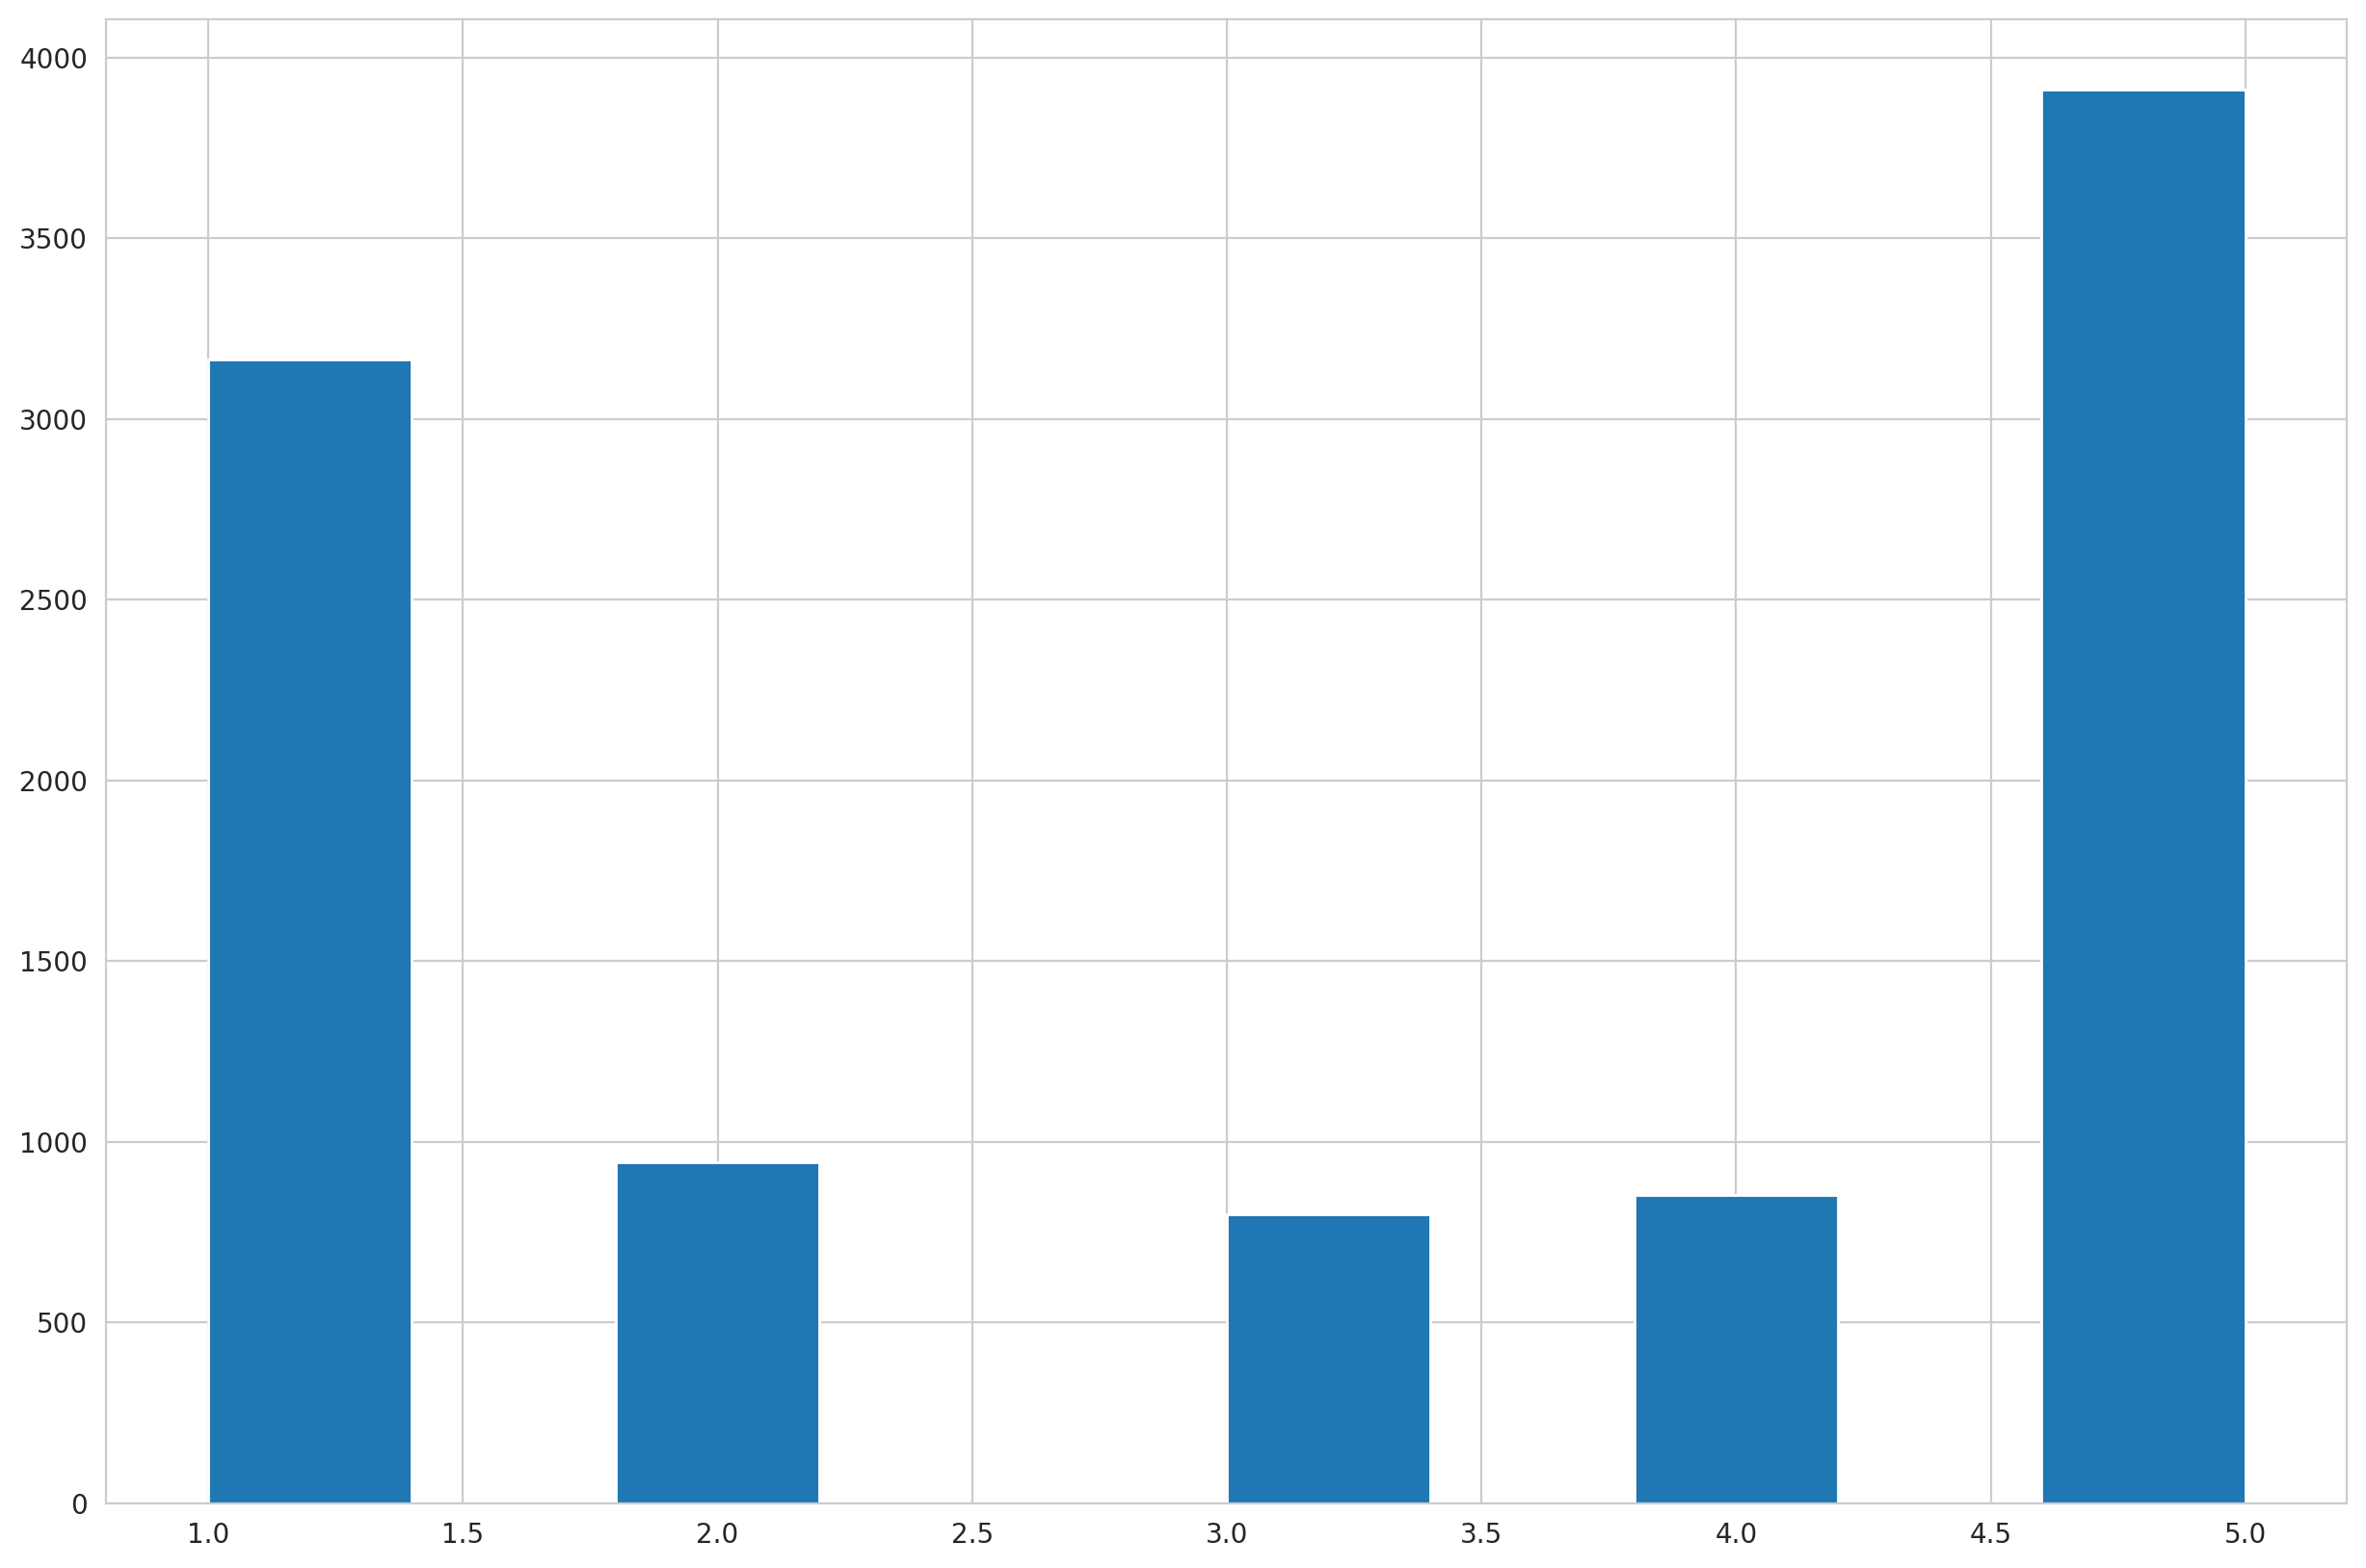

In [23]:
plt.hist(df_mbbrev['score'])
plt.show()

In [24]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokens,tokens_stopword_rm,tokens_stemmed
0,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method: credit card d...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0,"[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method, credit, ..."
1,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,perusahaan taksi andalan yang legendaris. maju...,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0,"[perusahaan, taksi, andalan, yang, legendaris....","[perusahaan, taksi, andalan, legendaris., maju...","[perusahaan, taksi, andalan, legendaris, maju,..."
2,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,getting better but can you please give the lic...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2,"[getting, better, but, can, you, please, give,...","[getting, better, please, give, licence, numbe...","[get, well, please, give, licence, number, tax..."
3,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"good app and service, but too many annoying ad...",4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2,"[good, app, and, service,, but, too, many, ann...","[good, app, service,, many, annoying, adverts]","[good, app, service, many, annoy, advert]"
4,6a1c2108-fb3d-4d79-807a-a6c44216cf77,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"nice app, thanks 👍🏾👍🏾",5,0,6.18.2,2025-09-13 02:01:38,"Dear Mr/Ms Andrie Wisnu , thank you for the ra...",2025-09-13 02:05:39,6.18.2,"[nice, app,, thanks, 👍🏾👍🏾]","[nice, app,, thanks, 👍🏾👍🏾]","[nice, app, thanks, ]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9664,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,great app. sangat membantu.,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127,"[great, app., sangat, membantu.]","[great, app., sangat, membantu.]","[great, app, sangat, membantu]"
9665,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"akhirnya setelah di blackberry, dibuat juga ap...",5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126,"[akhirnya, setelah, di, blackberry,, dibuat, j...","[akhirnya, blackberry,, dibuat, aplikasi, buat...","[akhir, blackberry, dibuat, aplikasi, buat, an..."
9666,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pagi jam 4 saya pesan taksi berjalan dengan ba...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126,"[pagi, jam, 4, saya, pesan, taksi, berjalan, d...","[pagi, jam, 4, pesan, taksi, berjalan, baik,, ...","[pagi, jam, 4, pesan, taksi, berjalan, baik, m..."
9667,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pertama kali make app ini gw seneng banget kar...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126,"[pertama, kali, make, app, ini, gw, seneng, ba...","[pertama, kali, make, app, gw, seneng, banget,...","[pertama, kali, make, app, saya, seneng, bange..."


# **Word Frequency Analysis**
Most Frequent Words / Most Common Words

In [25]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipython-input-2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


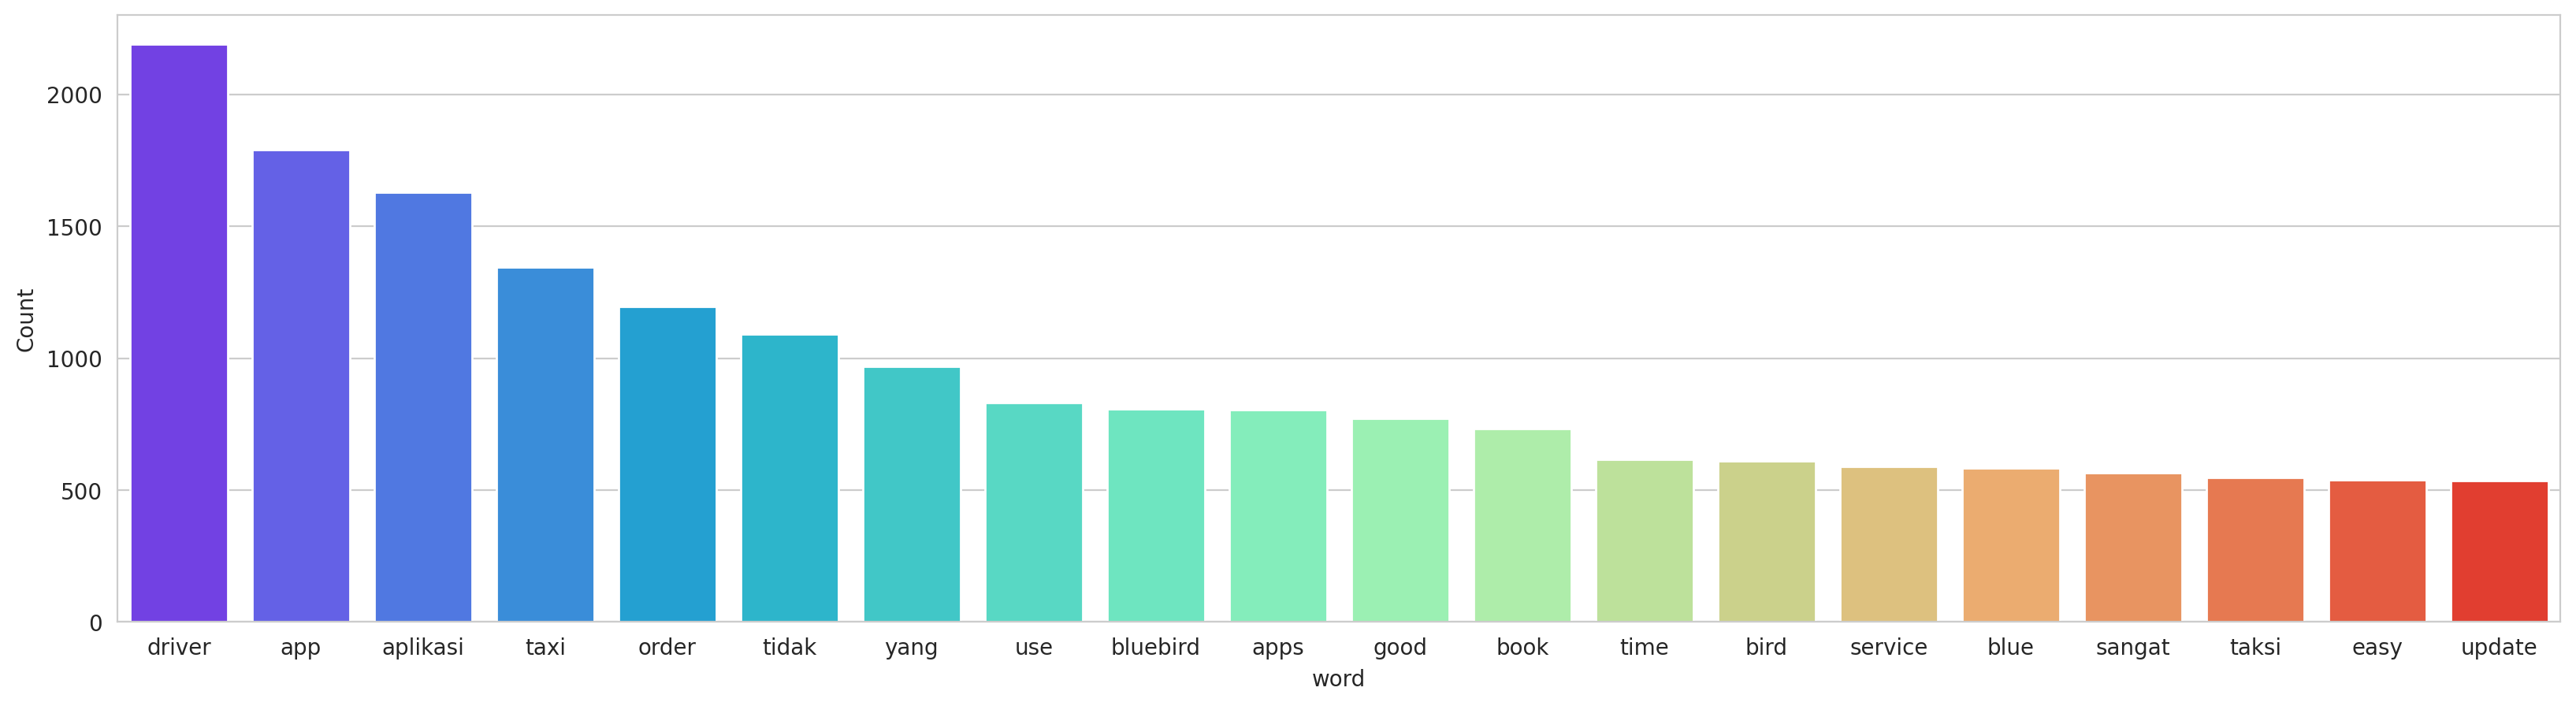

In [26]:
freq_words(df_mbbrev['tokens_stemmed'].apply(lambda x: ' '.join(x)), 20)

In [27]:
custom_stopwords = {"driver", "aplikasi", "app", "car", "taxi", "taksi", "apps", "bluebird", "blue", "bird", "order", "book"}

df_mbbrev['Cleaned_Text'] = df_mbbrev['tokens_stemmed'].apply(
    lambda tokens: ' '.join([word for word in tokens if word not in custom_stopwords])
)

print(df_mbbrev[['tokens_stemmed', 'Cleaned_Text']].head())


                                      tokens_stemmed  \
0  [selalu, gagal, add, payment, method, credit, ...   
1  [perusahaan, taksi, andalan, legendaris, maju,...   
2  [get, well, please, give, licence, number, tax...   
3          [good, app, service, many, annoy, advert]   
4                              [nice, app, thanks, ]   

                                        Cleaned_Text  
0  selalu gagal add payment method credit card er...  
1               perusahaan andalan legendaris maju u  
2  get well please give licence number well pd nu...  
3                     good service many annoy advert  
4                                       nice thanks   


In [28]:
df_mbbrev['content'] = df_mbbrev['Cleaned_Text'].astype(str)

In [29]:
df_to_save = df_mbbrev.drop(columns=["tokens", "tokens_stopword_rm", "Cleaned_Text", "Cleaned_Text", "tokens_stemmed"])

df_to_save.to_csv("mybluebird_clean.csv", index=False)



In [30]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokens,tokens_stopword_rm,tokens_stemmed,Cleaned_Text
0,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method credit card er...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0,"[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method, credit, ...",selalu gagal add payment method credit card er...
1,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,perusahaan andalan legendaris maju u,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0,"[perusahaan, taksi, andalan, yang, legendaris....","[perusahaan, taksi, andalan, legendaris., maju...","[perusahaan, taksi, andalan, legendaris, maju,...",perusahaan andalan legendaris maju u
2,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,get well please give licence number well pd nu...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2,"[getting, better, but, can, you, please, give,...","[getting, better, please, give, licence, numbe...","[get, well, please, give, licence, number, tax...",get well please give licence number well pd nu...
3,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,good service many annoy advert,4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2,"[good, app, and, service,, but, too, many, ann...","[good, app, service,, many, annoying, adverts]","[good, app, service, many, annoy, advert]",good service many annoy advert
4,6a1c2108-fb3d-4d79-807a-a6c44216cf77,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,nice thanks,5,0,6.18.2,2025-09-13 02:01:38,"Dear Mr/Ms Andrie Wisnu , thank you for the ra...",2025-09-13 02:05:39,6.18.2,"[nice, app,, thanks, 👍🏾👍🏾]","[nice, app,, thanks, 👍🏾👍🏾]","[nice, app, thanks, ]",nice thanks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9664,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,great sangat membantu,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127,"[great, app., sangat, membantu.]","[great, app., sangat, membantu.]","[great, app, sangat, membantu]",great sangat membantu
9665,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,akhir blackberry dibuat buat androidsemoga sem...,5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126,"[akhirnya, setelah, di, blackberry,, dibuat, j...","[akhirnya, blackberry,, dibuat, aplikasi, buat...","[akhir, blackberry, dibuat, aplikasi, buat, an...",akhir blackberry dibuat buat androidsemoga sem...
9666,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pagi jam 4 pesan berjalan baik muncul notifika...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126,"[pagi, jam, 4, saya, pesan, taksi, berjalan, d...","[pagi, jam, 4, pesan, taksi, berjalan, baik,, ...","[pagi, jam, 4, pesan, taksi, berjalan, baik, m...",pagi jam 4 pesan berjalan baik muncul notifika...
9667,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pertama kali make saya seneng banget saya trac...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126,"[pertama, kali, make, app, ini, gw, seneng, ba...","[pertama, kali, make, app, gw, seneng, banget,...","[pertama, kali, make, app, saya, seneng, bange...",pertama kali make saya seneng banget saya trac...


# Sentiment Analysis

In [31]:
from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_mbbrev['sentiment_polarity'] = df_mbbrev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_mbbrev['sentiment_subjective'] = df_mbbrev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [32]:
df_mbbrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,selalu gagal add payment method credit card er...,4,0.000000,0.000000
1,perusahaan andalan legendaris maju u,5,0.000000,0.000000
2,get well please give licence number well pd nu...,3,-0.333333,0.533333
3,good service many annoy advert,4,0.600000,0.550000
4,nice thanks,5,0.400000,0.600000
...,...,...,...,...
9664,great sangat membantu,4,0.800000,0.750000
9665,akhir blackberry dibuat buat androidsemoga sem...,5,0.000000,0.000000
9666,pagi jam 4 pesan berjalan baik muncul notifika...,4,0.000000,0.000000
9667,pertama kali make saya seneng banget saya trac...,2,0.000000,0.000000


In [33]:
# 50 Positive Review
df_positive = df_mbbrev[df_mbbrev['sentiment_polarity'] > 0].sample(50, random_state=42)

# 50 Negative Review
df_negative = df_mbbrev[df_mbbrev['sentiment_polarity'] < 0].sample(50, random_state=42)

# Merge
df_sampled = pd.concat([df_positive, df_negative])

# Tampilkan hanya kolom yang diinginkan
df_sampled = df_sampled.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective"]]

df_sampled.head(10)

,content,score,sentiment_polarity,sentiment_subjective
8473,useful easy use everytime always come time via...,5,0.366667,0.416667
9229,good service,4,0.700000,0.600000
2769,easy use,5,0.433333,0.833333
5183,use huge fan more fact forcefully try advance ...,2,0.163889,0.683333
9277,good,5,0.700000,0.600000
6771,love make travel easy convenient live track th...,5,0.293939,0.566667
3530,share loc bergerak real time,2,0.200000,0.300000
9547,sangat berguna coba beberapa kali selalu berha...,4,0.300000,0.300000
3506,realible trust good manner,5,0.700000,0.600000
3892,good good verry good really happy,5,0.725000,0.700000


Positive Review

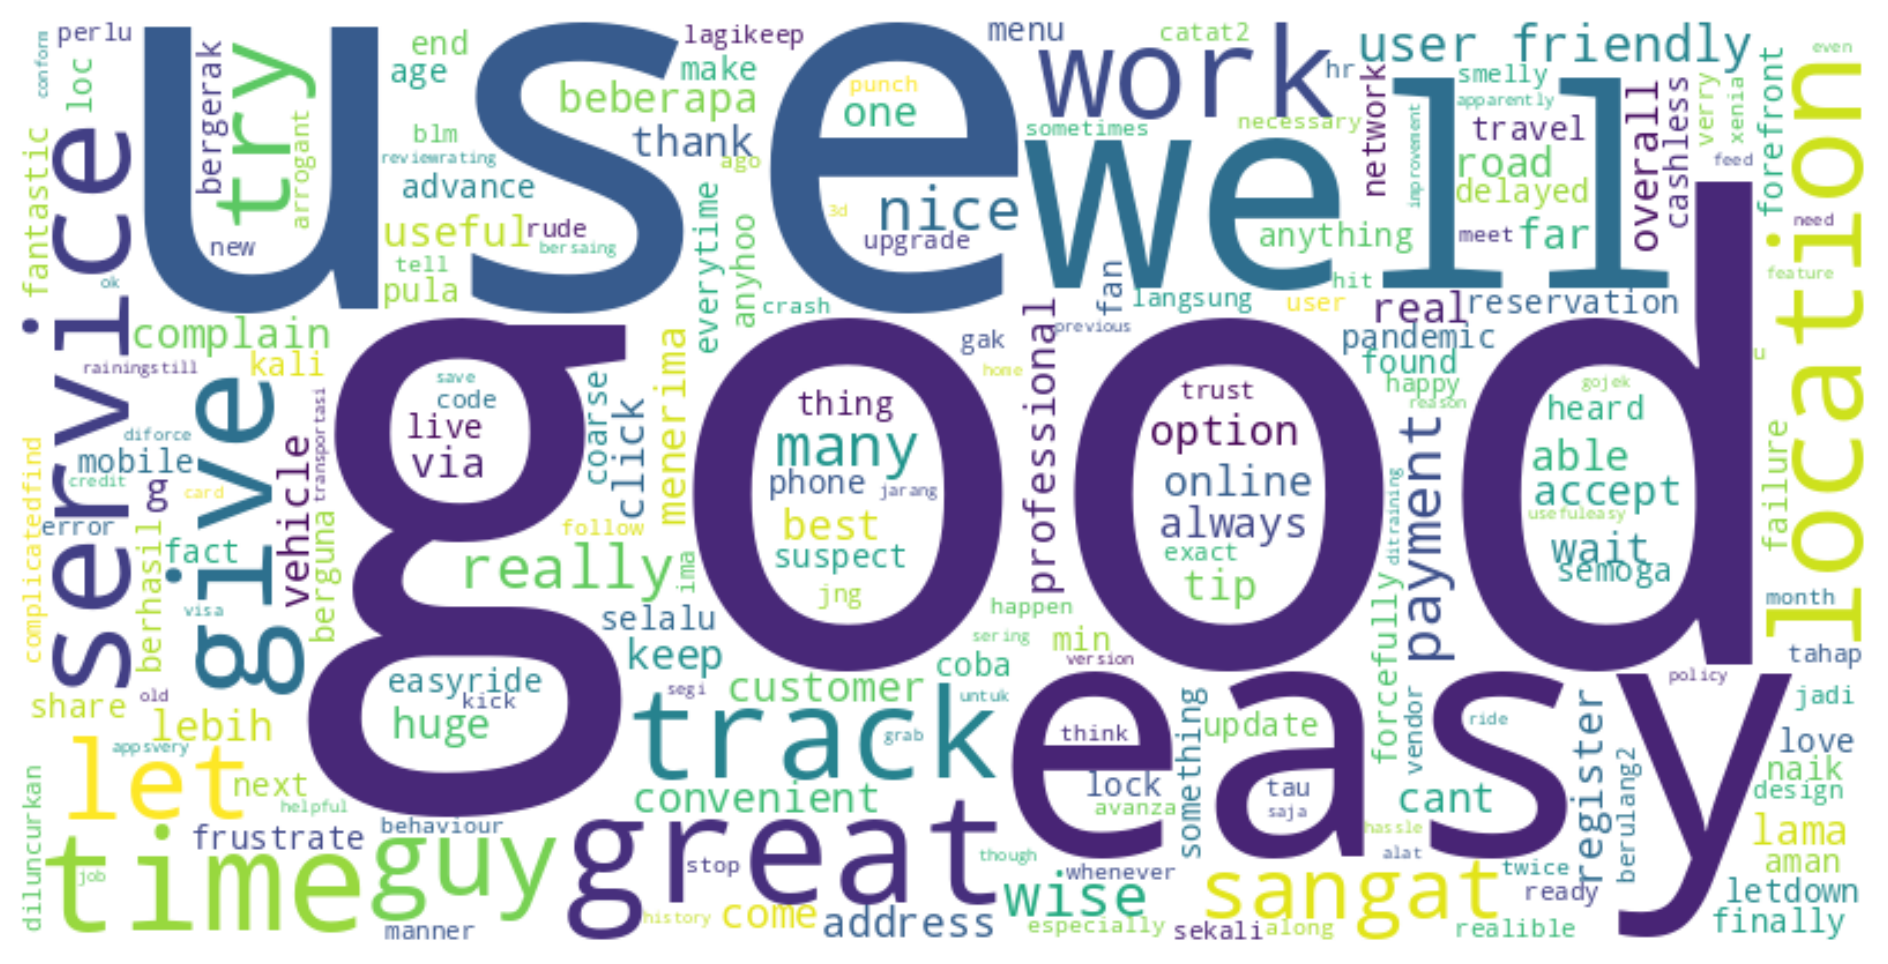

In [36]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Gabungkan semua teks jadi satu
text = " ".join(df_positive['content'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Negative Review

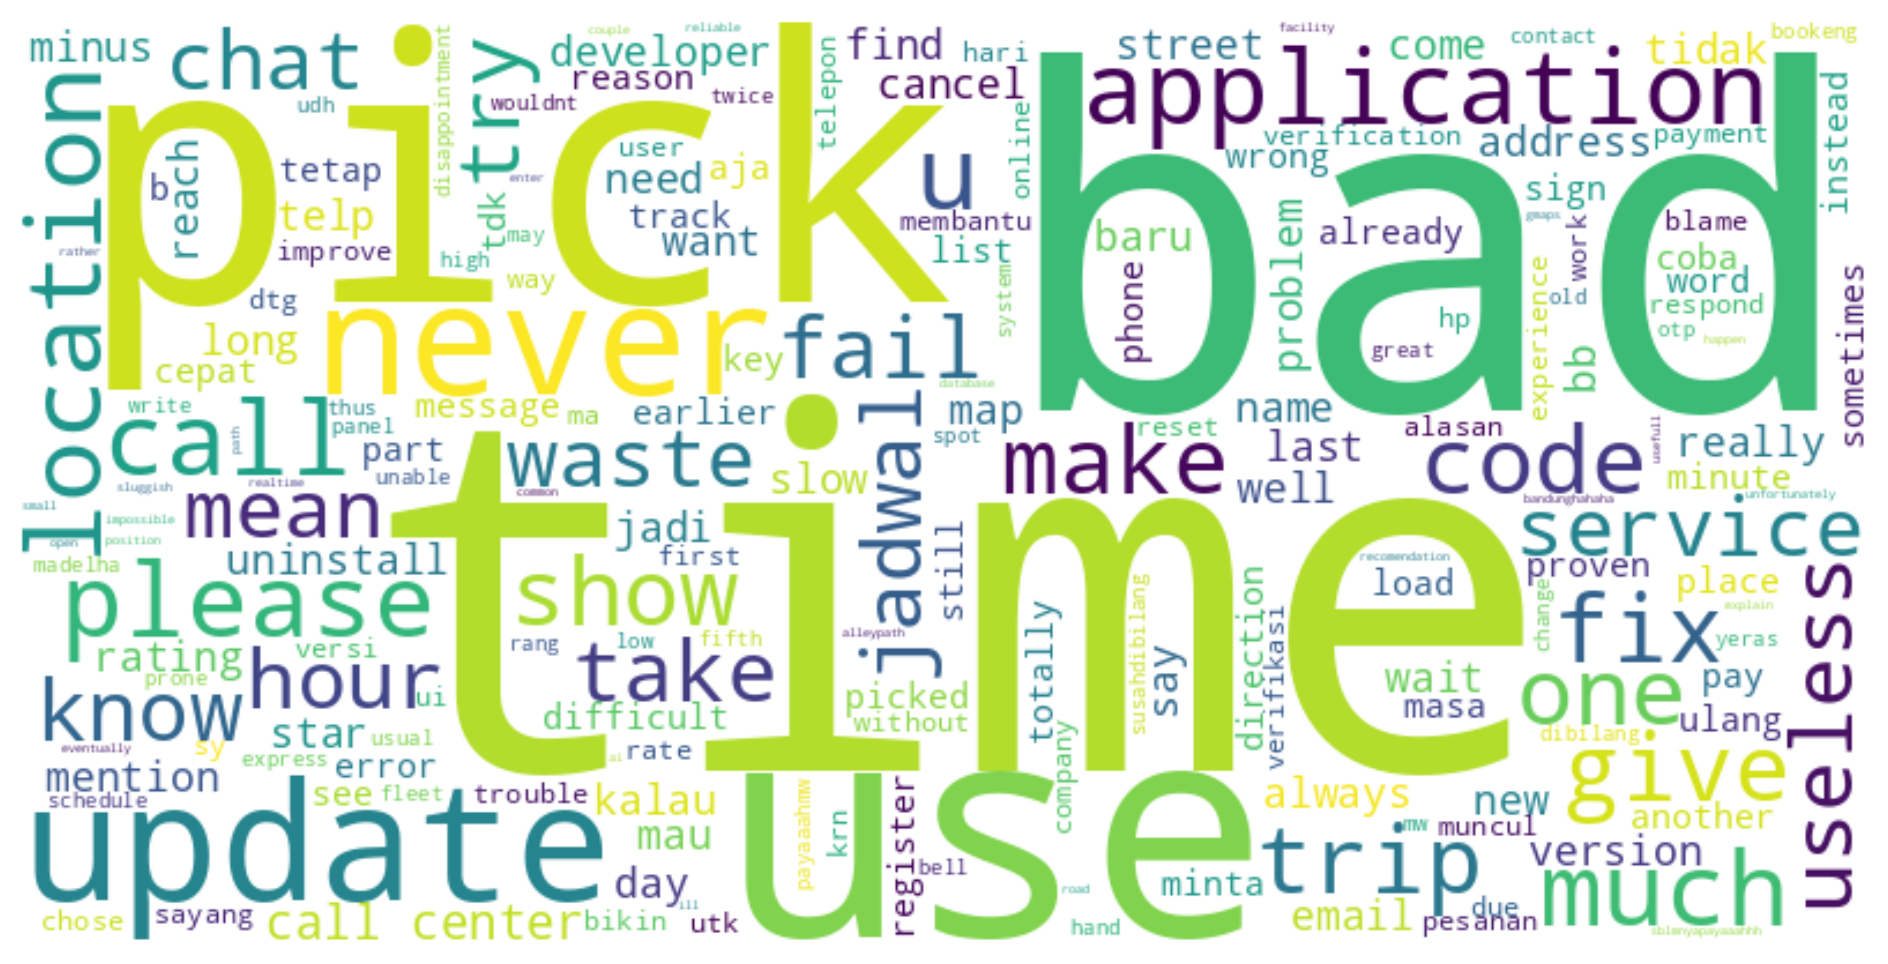

In [37]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Gabungkan semua teks jadi satu
text = " ".join(df_negative['content'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Vector Count

In [38]:
# texts = df_mbbrev['content'].astype(str).tolist()
texts = df_sampled['content'].astype(str).tolist()

# Inisialisasi CountVectorizer
vectorizer = CountVectorizer()

# Fit dan transform
X = vectorizer.fit_transform(texts)

# Konversi ke DataFrame agar lebih mudah dibaca
import pandas as pd
cv_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Gabungkan dengan df jika ingin
df_cv = pd.concat([df_sampled.reset_index(drop=True), cv_df.reset_index(drop=True)], axis=1)

# Simpan ke CSV
df_cv.to_csv("mybluebird_clean_cv.csv", index=False)

df_cv.head()

,content,score,sentiment_polarity,sentiment_subjective,15,24,30,300000,3d,able,...,would,wouldnt,write,wrong,xenia,xl,ya,yang,yeras,you
0,useful easy use everytime always come time via...,5,0.366667,0.416667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,good service,4,0.700000,0.600000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,easy use,5,0.433333,0.833333,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,use huge fan more fact forcefully try advance ...,2,0.163889,0.683333,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,good,5,0.700000,0.600000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
